Dataset Preview


Year,State,District,Soil_Type,Soil_pH,Nitrogen,Phosphorus,Potassium,Avg_Temperature_C,Rainfall_mm,Humidity_%,Irrigation_Type,Crop,Yield_t_per_hectare,Market_Price_per_ton,Profit_Index
2016,Tamil Nadu,Guntur,Red,6.52,32,64,56,24.1,1136,73,Sprinkler,Sugarcane,4.08,3163,12.91
2020,Andhra Pradesh,Coimbatore,Black,8.06,34,24,94,34.3,708,92,Rainfed,Cotton,5.46,4518,24.67
2023,Telangana,Salem,Black,8.42,70,21,48,37.9,1179,51,Rainfed,Cotton,5.86,4485,26.28
2019,Telangana,Krishna,Clay,5.69,31,59,91,31.0,673,65,Drip,Maize,2.21,2223,4.91
2023,Maharashtra,Warangal,Sandy,5.7,29,11,38,23.1,726,87,Rainfed,Rice,1.97,4547,8.96
2016,Maharashtra,Mysuru,Black,7.34,42,18,42,38.0,1147,87,Rainfed,Maize,6.21,5023,31.19
2016,Andhra Pradesh,Krishna,Black,6.43,76,20,52,34.9,1003,40,Drip,Sugarcane,4.1,5716,23.44
2022,Andhra Pradesh,Warangal,Alluvial,5.94,79,27,114,23.0,511,52,Drip,Cotton,3.16,2886,9.12
2020,Telangana,Salem,Alluvial,7.38,53,36,114,37.6,575,64,Sprinkler,Rice,5.78,2181,12.61
2018,Telangana,Karimnagar,Red,7.28,29,12,50,32.3,709,45,Sprinkler,Maize,5.35,5498,29.41


Year,State,District,Soil_Type,Soil_pH,Nitrogen,Phosphorus,Potassium,Avg_Temperature_C,Rainfall_mm,Humidity_%,Irrigation_Type,Crop,Yield_t_per_hectare,Market_Price_per_ton,Profit_Index,Yield_Category
2016,Tamil Nadu,Guntur,Red,6.52,32,64,56,24.1,1136,73,Sprinkler,Sugarcane,4.08,3163,12.91,High
2020,Andhra Pradesh,Coimbatore,Black,8.06,34,24,94,34.3,708,92,Rainfed,Cotton,5.46,4518,24.67,High
2023,Telangana,Salem,Black,8.42,70,21,48,37.9,1179,51,Rainfed,Cotton,5.86,4485,26.28,High
2019,Telangana,Krishna,Clay,5.69,31,59,91,31.0,673,65,Drip,Maize,2.21,2223,4.91,Medium
2023,Maharashtra,Warangal,Sandy,5.7,29,11,38,23.1,726,87,Rainfed,Rice,1.97,4547,8.96,Low
2016,Maharashtra,Mysuru,Black,7.34,42,18,42,38.0,1147,87,Rainfed,Maize,6.21,5023,31.19,High
2016,Andhra Pradesh,Krishna,Black,6.43,76,20,52,34.9,1003,40,Drip,Sugarcane,4.1,5716,23.44,High
2022,Andhra Pradesh,Warangal,Alluvial,5.94,79,27,114,23.0,511,52,Drip,Cotton,3.16,2886,9.12,Medium
2020,Telangana,Salem,Alluvial,7.38,53,36,114,37.6,575,64,Sprinkler,Rice,5.78,2181,12.61,High
2018,Telangana,Karimnagar,Red,7.28,29,12,50,32.3,709,45,Sprinkler,Maize,5.35,5498,29.41,High


Average Market Price by Crop


Crop
Cotton       3673.341176
Groundnut    3530.174419
Maize        3572.879518
Millets      3765.096386
Rice         3452.864516
Sugarcane    3502.415205
Name: Market_Price_per_ton, dtype: float64

Most profitable crop: Millets
Sample Crop Predictions
['Sugarcane' 'Millets' 'Rice' 'Maize' 'Sugarcane' 'Cotton' 'Sugarcane'
 'Rice' 'Cotton' 'Millets']
Predicted Yield
[4.761  4.7641 3.9782 3.6203 3.4865 4.5748 4.3282 4.4507 3.7678 4.516 ]


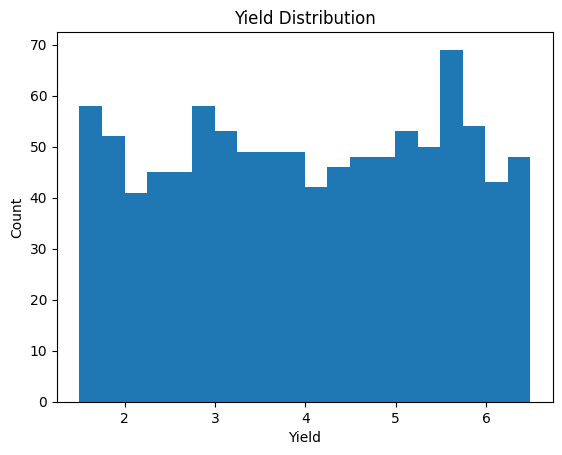

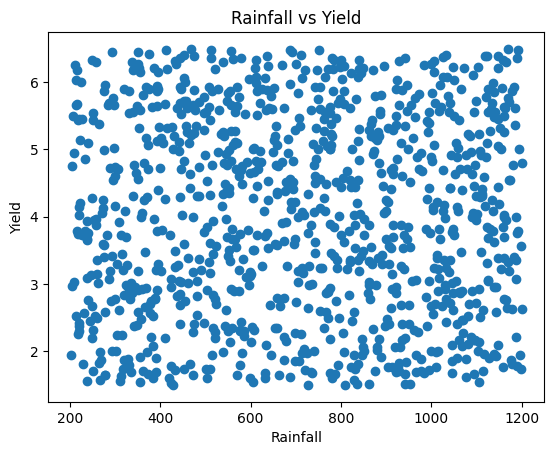

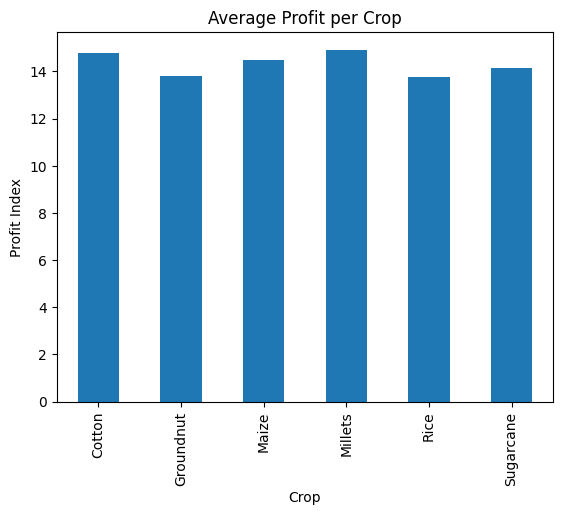

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load dataset from Databricks Volume
data = pd.read_csv("/Volumes/workspace/dataengineer/volume1/crop_prediction_dataset.csv")

print("Dataset Preview")
display(data)

# -----------------------
# Threshold Identification
# -----------------------

def yield_category(y):
    if y < 2:
        return "Low"
    elif y < 4:
        return "Medium"
    else:
        return "High"

data["Yield_Category"] = data["Yield_t_per_hectare"].apply(yield_category)

display(data)

# -----------------------
# Most Sold Crop in Area
# -----------------------

sales = data.groupby("Crop")["Market_Price_per_ton"].mean()

print("Average Market Price by Crop")
display(sales)

best_crop = sales.idxmax()
print("Most profitable crop:", best_crop)

# -----------------------
# ML Model - Crop Prediction
# -----------------------

features = ["Rainfall_mm","Avg_Temperature_C","Humidity_%","Nitrogen","Phosphorus","Potassium"]

X = data[features]
y = data["Crop"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

prediction = model.predict(X_test)

print("Sample Crop Predictions")
print(prediction[:10])

# -----------------------
# Yield Prediction Model
# -----------------------

y2 = data["Yield_t_per_hectare"]

rf = RandomForestRegressor()
rf.fit(X_train,y2.loc[X_train.index])

yield_pred = rf.predict(X_test)

print("Predicted Yield")
print(yield_pred[:10])

# -----------------------
# Visualization
# -----------------------

plt.hist(data["Yield_t_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Count")
plt.show()

plt.scatter(data["Rainfall_mm"],data["Yield_t_per_hectare"])
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

profit = data.groupby("Crop")["Profit_Index"].mean()

profit.plot(kind="bar")
plt.title("Average Profit per Crop")
plt.ylabel("Profit Index")
plt.show()